In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

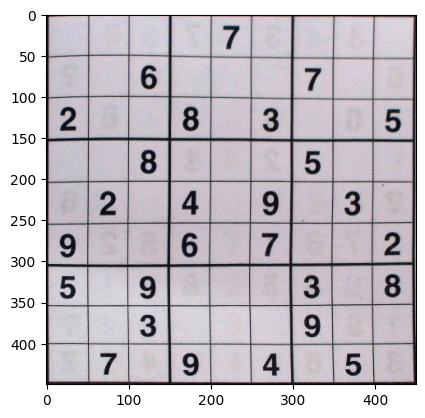

In [2]:
image = cv2.imread("data/sudoku_puzzles_book_33.jpg")

def threshold(im):
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    return cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV, 11, 2
    )

def reorder(points):
    """
    Takes four points from a contour of a square
    and returns them in a consistent order:
      - top-left
      - top-right,
      - bottom-right,
      - bottom-left.
    """
    points = points.reshape((4, 2))
    new_points = np.zeros((4, 2), dtype=np.float32)

    add = points.sum(1)
    new_points[0] = points[np.argmin(add)]  # top-left
    new_points[2] = points[np.argmax(add)]  # bottom-right

    diff = np.diff(points, axis=1)
    new_points[1] = points[np.argmin(diff)]  # top-right
    new_points[3] = points[np.argmax(diff)]  # bottom-left

    return new_points

def extract_grid(img, img_thresh, side=450):
    # Finding contours for the image
    contours, _ = cv2.findContours(
        img_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    contour = max(contours, key=cv2.contourArea)

    peri = cv2.arcLength(contour, True)  # frame for the sukoku

    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
    points = reorder(approx)

    pts1 = np.float32(points)
    pts2 = np.float32([[0, 0], [side, 0], [side, side], [0, side]])

    matrix = cv2.getPerspectiveTransform(pts1, pts2)
    warped = cv2.warpPerspective(img, matrix, (side, side))

    return warped

grid = extract_grid(image, threshold(image))
plt.imshow(grid)

In [3]:
np.set_printoptions(threshold=10000)

thresh = threshold(image)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(image, contours, -1, (0, 255, 0), 2)

array([[[203, 202, 206],
        [199, 198, 202],
        [201, 200, 204],
        ...,
        [232, 203, 198],
        [232, 203, 198],
        [233, 204, 199]],

       [[203, 202, 206],
        [198, 197, 201],
        [199, 197, 203],
        ...,
        [230, 201, 196],
        [230, 201, 196],
        [230, 201, 196]],

       [[204, 202, 208],
        [200, 198, 204],
        [199, 197, 203],
        ...,
        [229, 200, 196],
        [230, 199, 196],
        [230, 199, 196]],

       ...,

       [[180, 172, 172],
        [183, 175, 175],
        [183, 175, 175],
        ...,
        [146, 129, 140],
        [149, 132, 143],
        [153, 136, 147]],

       [[179, 171, 171],
        [183, 175, 175],
        [184, 176, 176],
        ...,
        [150, 133, 144],
        [153, 136, 147],
        [155, 138, 149]],

       [[177, 169, 169],
        [182, 174, 174],
        [185, 177, 177],
        ...,
        [153, 136, 147],
        [154, 137, 148],
        [156, 139, 150]]

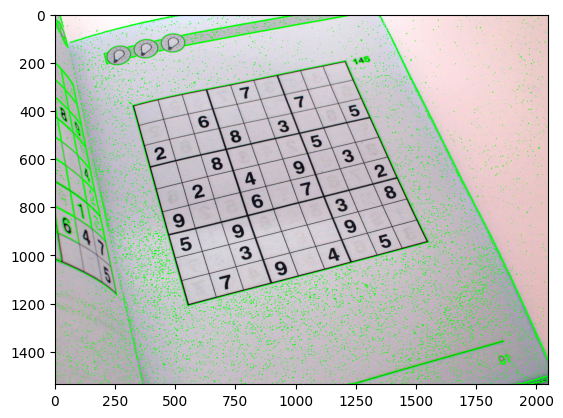

In [4]:
plt.imshow(image)

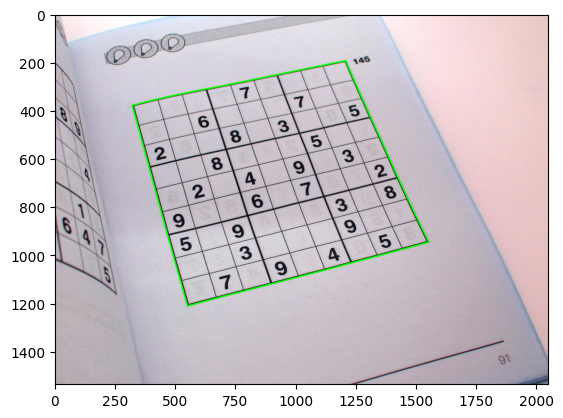

In [5]:
max_contour = max(contours, key=cv2.contourArea)
image = cv2.imread("data/sudoku_puzzles_book_33.jpg")

cv2.drawContours(image, max_contour, -1, (0, 255, 0), 5)
plt.imshow(image)

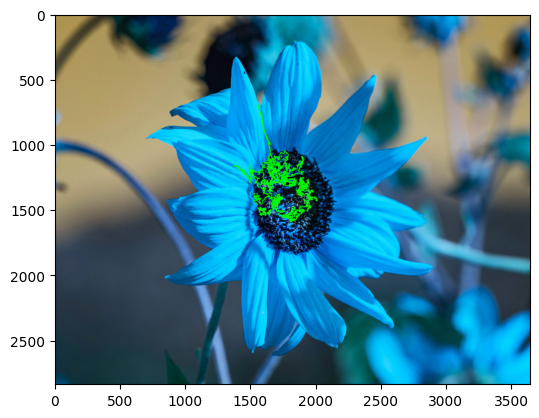

In [6]:
image_1 = cv2.imread("data/pexels-optical-chemist-340351297-31299772.jpg")

thresh_1 = threshold(image_1)

contours_1, _ = cv2.findContours(thresh_1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
max_contour_1 = max(contours_1, key=cv2.contourArea)

cv2.drawContours(image_1, max_contour_1, -1, (0, 255, 0), 5)
plt.imshow(image_1)

In [7]:
cv2.arcLength(max_contour_1, True), cv2.arcLength(max_contour, True)

(18931.796249628067, 3899.5688766241074)

In [8]:
cv2.approxPolyDP(max_contour, 0.02 * cv2.arcLength(max_contour, True), True)

array([[[1207,  193]],

       [[ 321,  379]],

       [[ 550, 1212]],

       [[1552,  947]]], dtype=int32)

In [9]:
cv2.approxPolyDP(max_contour_1, 0.02 * cv2.arcLength(max_contour_1, True), True)

array([[[1556,  692]],

       [[1814, 1590]]], dtype=int32)

In [10]:
approx = cv2.approxPolyDP(max_contour, 0.02 * cv2.arcLength(max_contour, True), True)
approx_1 = cv2.approxPolyDP(max_contour_1, 0.02 * cv2.arcLength(max_contour_1, True), True)
approx.shape, approx_1.shape

((4, 1, 2), (2, 1, 2))

In [11]:
def validate_contour(contour):
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
    return len(approx) == 4

validate_contour(max_contour_1), validate_contour(max_contour)

(False, True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(<matplotlib.image.AxesImage at 0x78ca3867e930>, True)

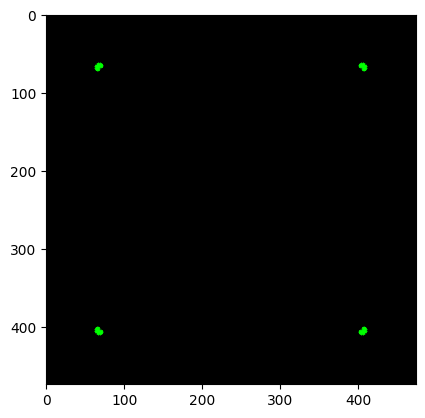

In [12]:
image_2 = cv2.imread("data/OIP-1977465204.jpg")
dummy_image = np.zeros((image_2.shape))

thresh_2 = threshold(image_2)

contours_2, _ = cv2.findContours(thresh_2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
max_contour_2 = max(contours_2, key=cv2.contourArea)

cv2.drawContours(dummy_image, max_contour_2, -1, (0, 255, 0), 5)
plt.imshow(dummy_image), validate_contour(max_contour_2)

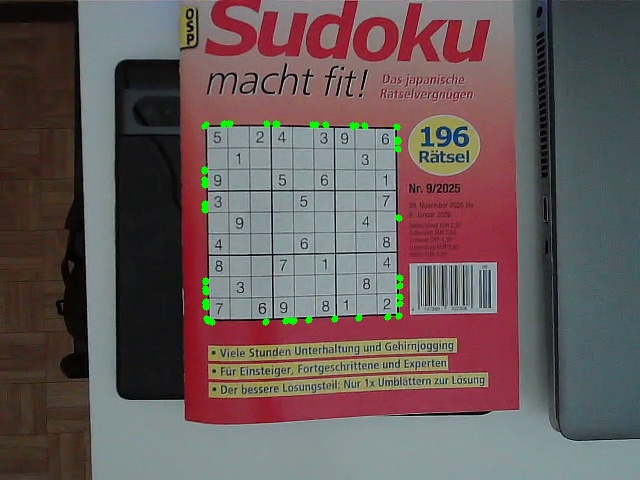

True   

In [37]:
from IPython.display import display, Image
import time

def view():

    def draw_contours(frame):
        thresh = threshold(frame)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        max_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(frame, max_contour, -1, (0, 255, 0), 5)
        return validate_contour(max_contour)

    cap = cv2.VideoCapture("data/output.mp4")
    display_handle=display(None, display_id=True)

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_before = frame.copy()
        status = draw_contours(frame)
        print(f"\r{status}  ", end="")
        _, im = cv2.imencode('.jpeg', frame)
        display_handle.update(Image(data=im.tobytes()))
        time.sleep(0.05)

    cap.release()
    return status, frame_before

ret, frame = view()

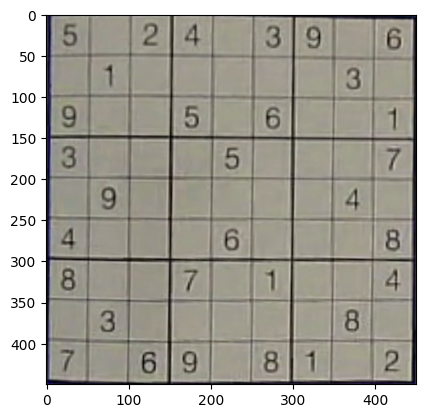

In [43]:
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
grid = extract_grid(frame, threshold(frame))
plt.imshow(grid)

In [44]:
from modules.image_parsing import InferenceEngine

inference_engine = InferenceEngine(grid)
preds = inference_engine.parse_to_numpy()
preds

/home/cian/sudoku-cracker/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/cian/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/cian/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/cian/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model

array([[5, ..., 6],
       ...,
       [7, ..., 2]], shape=(9, 9))

In [45]:
np.set_printoptions(threshold=10000)
preds

array([[5, 0, 2, 4, 0, 3, 9, 0, 6],
       [0, 1, 0, 0, 0, 0, 0, 3, 0],
       [9, 0, 0, 5, 0, 6, 0, 0, 1],
       [3, 0, 0, 0, 5, 0, 0, 0, 7],
       [0, 9, 0, 0, 0, 0, 0, 4, 0],
       [4, 0, 0, 0, 6, 0, 0, 0, 8],
       [8, 0, 0, 7, 0, 0, 0, 0, 4],
       [0, 3, 0, 0, 0, 0, 0, 8, 0],
       [7, 0, 6, 9, 0, 8, 1, 0, 2]])